# Advanced Clustering

## Hierarchical Clustering
- Build a tree (dendrogram) of clusters
- Two types: Agglomerative (bottom-up) and Divisive (top-down)

## DBSCAN
- Density-Based Spatial Clustering
- Finds clusters of arbitrary shape
- Handles noise/outliers well
- No need to specify K!

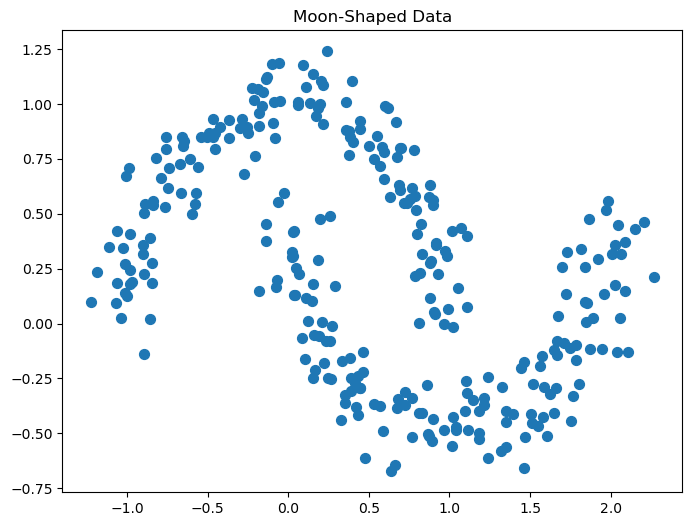

In [2]:
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
import numpy as np

# Create moon-shaped data (hard for K-Means!)
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=50)
plt.title("Moon-Shaped Data")
plt.show()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


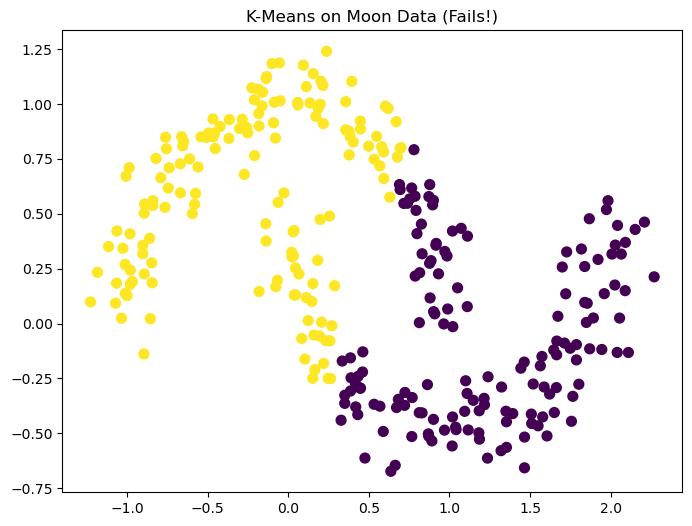

In [3]:
# K-Means on moon data (will fail!)
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=50)
plt.title("K-Means on Moon Data (Fails!)")
plt.show()

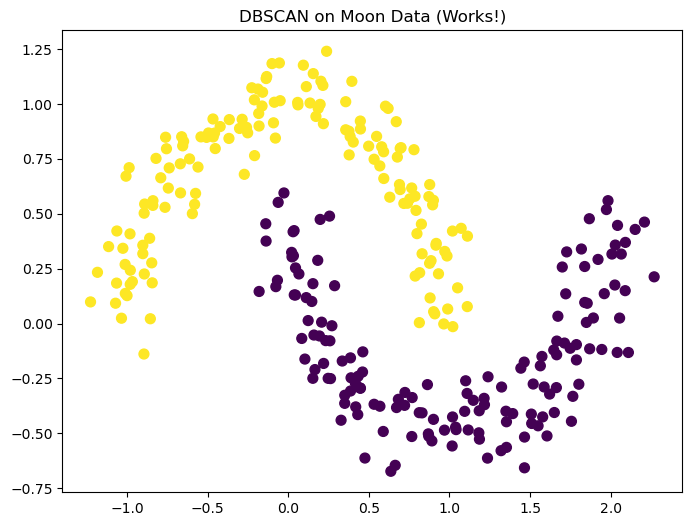

Number of clusters: 2
Number of noise points: 0


In [5]:
# DBSCAN on moon data (works!)
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# -1 means noise (outliers)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=50)
plt.title("DBSCAN on Moon Data (Works!)")
plt.show()

print(f"Number of clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"Number of noise points: {list(dbscan_labels).count(-1)}")

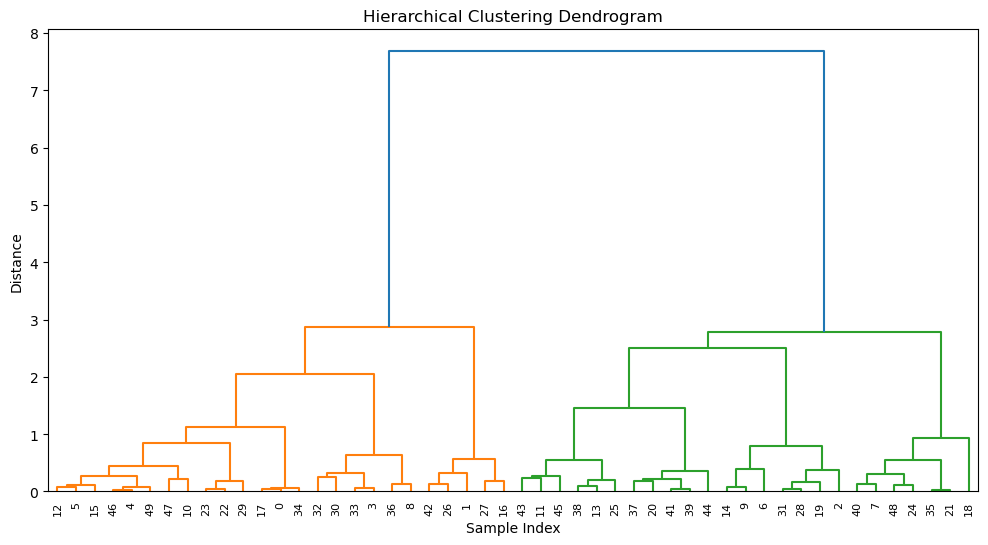

In [6]:
# Hierarchical Clustering
from scipy.cluster.hierarchy import dendrogram, linkage

# Create linkage matrix
linked = linkage(X[:50], method='ward')  # Use subset for visibility

# Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(linked, orientation='top', distance_sort='descending', show_leaf_counts=True)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Sample Index")
plt.ylabel("Distance")
plt.show()